# Spam Mail Classifier - Data Science Process

This notebook documents the end-to-end data science process used in the project. It covers the problem definition, dataset loading, exploratory data analysis, model loading, inference, and evaluation with the UCI SMS Spam Collection dataset.

The web application uses the Hugging Face model [`Goodmotion/spam-mail-classifier`](https://huggingface.co/Goodmotion/spam-mail-classifier) to classify text messages as `SPAM` or `NOSPAM`.


## 1. Problem Definition

The objective is to classify short text messages as:

- `SPAM`: unwanted, promotional, fraudulent, or suspicious messages.
- `NOSPAM`: legitimate messages.

The final product is a web application with three main views:

1. Exploratory data analysis of the SMS Spam Collection dataset.
2. Model evaluation results over labeled messages.
3. Interactive chat-style message classification.


## 2. Environment Setup

The Python dependencies are listed in `requirements.txt`. This notebook is self-contained: it defines its own dataset, inference, and evaluation functions instead of importing code from `app/`.


In [1]:
# Dependencies were installed from the project terminal.
# On Windows, avoid reinstalling while this notebook kernel is running because pip can hit locked files.
INSTALL_REQUIREMENTS = False

if not INSTALL_REQUIREMENTS:
    print("Dependencies are already installed. Set INSTALL_REQUIREMENTS = True only after restarting the kernel if you need to reinstall.")
else:
    from pathlib import Path

    project_root = Path.cwd()
    if not (project_root / "requirements.txt").exists():
        project_root = project_root.parent

    requirements_file = project_root / "requirements.txt"
    if not requirements_file.exists():
        raise FileNotFoundError(f"Could not find requirements.txt from {Path.cwd()}")

    %pip install -r "{requirements_file}"


Dependencies are already installed. Set INSTALL_REQUIREMENTS = True only after restarting the kernel if you need to reinstall.


In [2]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "app").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

print("Project root:", PROJECT_ROOT)
print("Python executable:", sys.executable)


Project root: c:\Users\mavel\Downloads\GitHub\detector_spam
Python executable: c:\Users\mavel\Downloads\GitHub\detector_spam\.venv\Scripts\python.exe


In [3]:
from functools import lru_cache
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

DATA_DIR = PROJECT_ROOT / "data"
RAW_FILE = DATA_DIR / "SMSSpamCollection"
DATASET_SOURCE = str(RAW_FILE)


def ensure_dataset() -> Path:
    """Return the local UCI SMS Spam Collection dataset file."""
    if not RAW_FILE.exists():
        raise FileNotFoundError(
            f"Dataset not found at {RAW_FILE}. Place the SMSSpamCollection file in {DATA_DIR}."
        )

    return RAW_FILE


@lru_cache(maxsize=1)
def load_sms_dataset() -> pd.DataFrame:
    """Load the SMS Spam Collection as a normalized dataframe."""
    dataframe = pd.read_csv(
        ensure_dataset(),
        sep="\t",
        header=None,
        names=["label", "message"],
        encoding="utf-8",
    )
    dataframe["label"] = dataframe["label"].str.upper().replace({"HAM": "NOSPAM"})
    dataframe["message"] = dataframe["message"].astype(str)
    return dataframe


def with_text_features(dataframe: pd.DataFrame) -> pd.DataFrame:
    featured = dataframe.copy()
    featured["characters"] = featured["message"].str.len()
    featured["words"] = featured["message"].str.split().str.len()
    return featured


def common_terms(dataframe: pd.DataFrame, limit: int = 15) -> pd.DataFrame:
    stop_words = {
        "a", "an", "and", "are", "as", "at", "be", "by", "for", "from",
        "in", "is", "it", "me", "my", "of", "on", "or", "that", "the",
        "to", "u", "ur", "with", "you", "your",
    }
    terms = (
        dataframe["message"]
        .str.lower()
        .str.replace(r"[^a-z0-9\s]", " ", regex=True)
        .str.split()
        .explode()
    )
    terms = terms[terms.str.len().gt(2) & ~terms.isin(stop_words)]
    return terms.value_counts().head(limit).rename_axis("term").reset_index(name="count")


def dataset_summary() -> dict:
    dataframe = load_sms_dataset()
    counts = dataframe["label"].value_counts().to_dict()
    enriched = with_text_features(dataframe)
    spam_count = int(counts.get("SPAM", 0))
    nospam_count = int(counts.get("NOSPAM", 0))
    return {
        "source": DATASET_SOURCE,
        "rows": int(len(dataframe)),
        "labels": {label: int(count) for label, count in counts.items()},
        "spam_rate": round(spam_count / len(dataframe), 4),
        "nospam_rate": round(nospam_count / len(dataframe), 4),
        "avg_characters": round(float(enriched["characters"].mean()), 2),
        "avg_words": round(float(enriched["words"].mean()), 2),
        "max_characters": int(enriched["characters"].max()),
    }


def dataset_profile() -> dict:
    dataframe = with_text_features(load_sms_dataset())
    label_distribution = (
        dataframe["label"]
        .value_counts()
        .rename_axis("label")
        .reset_index(name="count")
        .sort_values("label")
    )
    length_by_label = dataframe.groupby("label", as_index=False).agg(
        avg_characters=("characters", "mean"),
        median_characters=("characters", "median"),
        avg_words=("words", "mean"),
        median_words=("words", "median"),
    )
    return {
        "dataframe": dataframe,
        "label_distribution": label_distribution,
        "length_by_label": length_by_label.round(2),
        "common_terms": common_terms(dataframe, limit=15),
    }


def evaluation_sample(limit: int = 300) -> pd.DataFrame:
    dataframe = load_sms_dataset()
    limit = max(2, min(limit, len(dataframe)))
    per_label = max(1, limit // dataframe["label"].nunique())
    sample = (
        dataframe.groupby("label", group_keys=False)
        .apply(lambda group: group.sample(min(len(group), per_label), random_state=42))
        .sample(frac=1, random_state=42)
    )

    if len(sample) < limit:
        remainder = dataframe.drop(sample.index).sample(
            min(limit - len(sample), len(dataframe) - len(sample)),
            random_state=42,
        )
        sample = pd.concat([sample, remainder])

    return sample.sample(frac=1, random_state=42).head(limit).reset_index(drop=True)


sns.set_theme(style="whitegrid")
print("Dataset file:", RAW_FILE)


Dataset file: c:\Users\mavel\Downloads\GitHub\detector_spam\data\SMSSpamCollection


## 3. Dataset Loading

The project uses the local UCI SMS Spam Collection dataset stored at `data/SMSSpamCollection`. The helper function `load_sms_dataset()` reads that file and normalizes the original labels:

- `ham` -> `NOSPAM`
- `spam` -> `SPAM`


In [4]:
df = load_sms_dataset()
df.head()


,label,message
0,NOSPAM,"Go until jurong point, crazy.. Available only ..."
1,NOSPAM,Ok lar... Joking wif u oni...
2,SPAM,Free entry in 2 a wkly comp to win FA Cup fina...
3,NOSPAM,U dun say so early hor... U c already then say...
4,NOSPAM,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


## 4. Exploratory Data Analysis

This section computes descriptive statistics used by the Streamlit tab **Analisis exploratorio de datos**.


In [6]:
summary = dataset_summary()
summary


{'source': 'c:\\Users\\mavel\\Downloads\\GitHub\\detector_spam\\data\\SMSSpamCollection',
 'rows': 5572,
 'labels': {'NOSPAM': 4825, 'SPAM': 747},
 'spam_rate': 0.1341,
 'nospam_rate': 0.8659,
 'avg_characters': 80.49,
 'avg_words': 15.6,
 'max_characters': 910}

In [7]:
profile = dataset_profile()
label_distribution = profile["label_distribution"]
length_by_label = profile["length_by_label"]
common_terms = profile["common_terms"]
eda_df = profile["dataframe"]

label_distribution


,label,count
0,NOSPAM,4825
1,SPAM,747


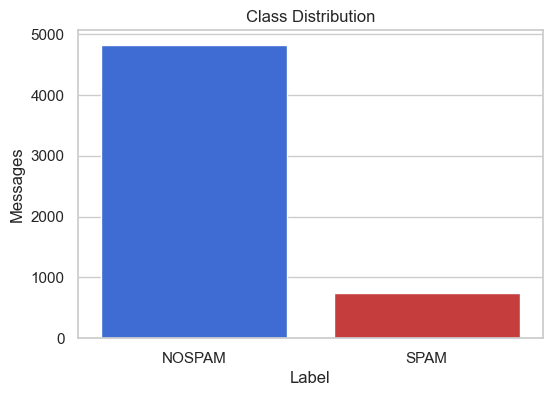

In [8]:
plt.figure(figsize=(6, 4))
sns.barplot(
    data=label_distribution,
    x="label",
    y="count",
    hue="label",
    palette={"NOSPAM": "#2563eb", "SPAM": "#dc2626"},
    legend=False,
)
plt.title("Class Distribution")
plt.xlabel("Label")
plt.ylabel("Messages")
plt.show()


In [9]:
length_by_label


,label,avg_characters,median_characters,avg_words,median_words
0,NOSPAM,71.48,52.0,14.31,11.0
1,SPAM,138.67,149.0,23.91,25.0


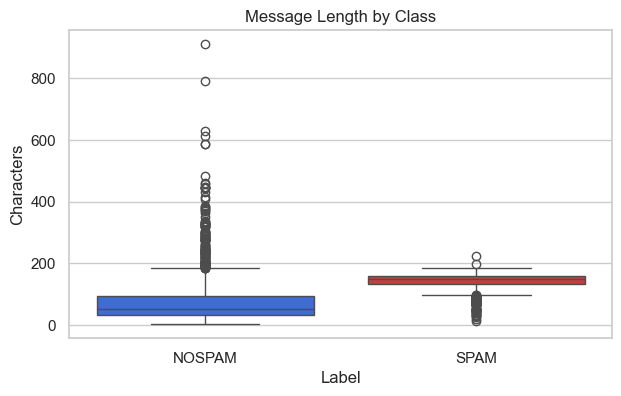

In [10]:
plt.figure(figsize=(7, 4))
sns.boxplot(
    data=eda_df,
    x="label",
    y="characters",
    hue="label",
    palette={"NOSPAM": "#2563eb", "SPAM": "#dc2626"},
    legend=False,
)
plt.title("Message Length by Class")
plt.xlabel("Label")
plt.ylabel("Characters")
plt.show()


In [11]:
common_terms.head(15)


,term,count
0,call,593
1,have,578
2,now,502
3,can,471
4,but,448
5,not,445
6,get,391
7,will,390
8,just,376
9,this,343


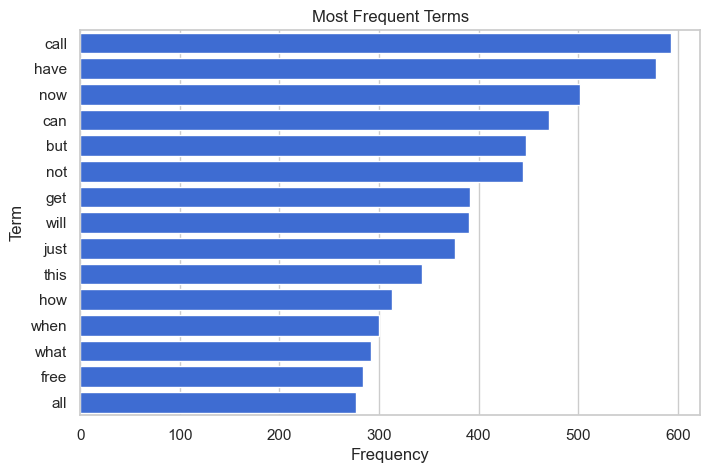

In [12]:
plt.figure(figsize=(8, 5))
sns.barplot(data=common_terms.head(15), y="term", x="count", color="#2563eb")
plt.title("Most Frequent Terms")
plt.xlabel("Frequency")
plt.ylabel("Term")
plt.show()


## 5. Model Loading and Single Message Classification

The notebook loads the Hugging Face tokenizer and model directly, applies the tokenizer, runs inference with PyTorch, converts logits to probabilities, and returns label, confidence, and class scores.

The following cell uses the notebook-defined `classify_text()` function.


In [ ]:
from functools import lru_cache
from typing import Iterable
import os
import warnings

from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

MODEL_NAME = "Goodmotion/spam-mail-classifier"
LABELS = ["NOSPAM", "SPAM"]
CACHE_DIR = PROJECT_ROOT / ".cache" / "huggingface"
os.environ.setdefault("HF_HOME", str(CACHE_DIR))
os.environ.setdefault("TRANSFORMERS_CACHE", str(CACHE_DIR / "transformers"))
warnings.filterwarnings("ignore", message="Using `TRANSFORMERS_CACHE`.*", category=FutureWarning)


def model_runtime_available() -> bool:
    """Return True when PyTorch can be imported for model inference."""
    try:
        load_torch()
    except RuntimeError as error:
        print(error)
        return False
    return True


@lru_cache(maxsize=1)
def load_torch():
    """Import torch only when model inference is requested."""
    try:
        import torch
    except OSError as error:
        raise RuntimeError(
            "PyTorch could not be loaded in this environment. "
            "The EDA cells do not require PyTorch. Reinstall a compatible CPU build of torch "
            "before running model inference or evaluation."
        ) from error
    return torch


@lru_cache(maxsize=1)
def load_model():
    """Load the tokenizer and model once for this notebook session."""
    from transformers import AutoModelForSequenceClassification, AutoTokenizer

    load_torch()
    try:
        tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, local_files_only=True)
        model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, local_files_only=True)
    except OSError:
        tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
        model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)

    model.eval()
    return tokenizer, model


def normalize_label(label: str) -> str:
    normalized = str(label).strip().upper().replace(" ", "")
    if normalized in {"HAM", "NOTSPAM", "NO-SPAM", "NONSPAM", "NOSPAM"}:
        return "NOSPAM"
    if normalized in {"SPAM", "JUNK"}:
        return "SPAM"
    return normalized


def model_labels(model):
    id2label = getattr(model.config, "id2label", None)
    if not id2label:
        return LABELS

    labels = [normalize_label(id2label.get(index, LABELS[index])) for index in range(len(LABELS))]
    if set(labels) == {"LABEL_0", "LABEL_1"}:
        return LABELS
    return labels


def classify_texts(texts: Iterable[str]):
    clean_texts = [text.strip() for text in texts if text and text.strip()]
    if not clean_texts:
        return []

    torch = load_torch()
    tokenizer, model = load_model()
    inputs = tokenizer(
        clean_texts,
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors="pt",
    )

    with torch.no_grad():
        outputs = model(**inputs)

    probabilities = torch.softmax(outputs.logits, dim=1)
    labels = model_labels(model)
    results = []

    for text, probability in zip(clean_texts, probabilities):
        predicted_index = int(torch.argmax(probability).item())
        scores = {label: round(float(score), 4) for label, score in zip(labels, probability.tolist())}
        results.append({
            "text": text,
            "label": labels[predicted_index],
            "confidence": round(float(probability[predicted_index].item()), 4),
            "scores": scores,
        })

    return results


def classify_text(text: str):
    results = classify_texts([text])
    return results[0] if results else None


def evaluate_messages(dataframe: pd.DataFrame, batch_size: int = 32) -> dict:
    if dataframe.empty:
        return {
            "accuracy": 0.0,
            "count": 0,
            "confusion_matrix": [],
            "classification_report": {},
            "predictions": [],
        }

    predictions = []
    messages = dataframe["message"].astype(str).tolist()
    for start in range(0, len(messages), batch_size):
        predictions.extend(classify_texts(messages[start : start + batch_size]))

    y_true = dataframe["label"].astype(str).str.upper().tolist()
    y_pred = [item["label"] for item in predictions]

    return {
        "accuracy": round(float(accuracy_score(y_true, y_pred)), 4),
        "count": len(y_true),
        "confusion_matrix": confusion_matrix(y_true, y_pred, labels=LABELS).tolist(),
        "classification_report": classification_report(
            y_true,
            y_pred,
            labels=LABELS,
            output_dict=True,
            zero_division=0,
        ),
        "predictions": predictions,
    }


print("Model:", MODEL_NAME)


In [ ]:
if model_runtime_available():
    classify_text("Urgent: Verify your account immediately.")
else:
    print("Model inference skipped because PyTorch is not available in this environment.")


In [ ]:
examples = [
    "Join us for a webinar on AI innovations",
    "Urgent: Verify your account immediately.",
    "Meeting rescheduled to 3 PM",
    "Claim your free prize now!",
]

if model_runtime_available():
    example_predictions = pd.DataFrame([classify_text(text) for text in examples])
    example_predictions
else:
    pd.DataFrame({"message": examples, "status": "Model inference skipped; PyTorch is not available."})


## 6. Model Evaluation on the Dataset

The evaluation uses a deterministic stratified sample from the dataset. This keeps the evaluation fast while ensuring both classes are represented.

The notebook-defined `evaluate_messages()` function computes accuracy, classification metrics, predictions, and the confusion matrix.


In [ ]:
eval_df = evaluation_sample(100)
eval_df["label"].value_counts()


In [ ]:
if model_runtime_available():
    evaluation = evaluate_messages(eval_df)
    print("Messages evaluated:", evaluation["count"])
    print("Accuracy:", evaluation["accuracy"])
    evaluation["confusion_matrix"]
else:
    evaluation = None
    print("Model evaluation skipped because PyTorch is not available in this environment.")


In [ ]:
if evaluation is not None:
    report = pd.DataFrame(evaluation["classification_report"]).transpose()
    report
else:
    print("Classification report skipped because model evaluation was not executed.")


In [ ]:
if evaluation is not None:
    ConfusionMatrixDisplay(
        confusion_matrix=evaluation["confusion_matrix"],
        display_labels=LABELS,
    ).plot(cmap="Blues")
    plt.title("Confusion Matrix")
    plt.show()
else:
    print("Confusion matrix skipped because model evaluation was not executed.")


In [ ]:
if evaluation is not None:
    prediction_rows = []
    for row, prediction in zip(eval_df.to_dict(orient="records"), evaluation["predictions"]):
        prediction_rows.append({
            "label_real": row["label"],
            "label_predicha": prediction["label"],
            "correcta": row["label"] == prediction["label"],
            "confianza": prediction["confidence"],
            "message": row["message"],
        })

    predictions_df = pd.DataFrame(prediction_rows)
    predictions_df.head(10)
else:
    predictions_df = pd.DataFrame()
    print("Prediction table skipped because model evaluation was not executed.")


In [ ]:
if not predictions_df.empty:
    correct_examples = predictions_df[predictions_df["correcta"]].head(5)
    incorrect_examples = predictions_df[~predictions_df["correcta"]].head(5)
    correct_examples, incorrect_examples
else:
    print("Example comparison skipped because model evaluation was not executed.")


## 7. Web Application Implementation

The production code is organized in the `app/` folder:

- `app/data.py`: loads, normalizes, summarizes, profiles, and samples the local UCI dataset from `data/SMSSpamCollection`.
- `app/model.py`: loads the Hugging Face model, classifies messages, and evaluates predictions with scikit-learn metrics.
- `app/streamlit_app.py`: implements the three required tabs: EDA, model evaluation, and chat-style classification.
- `app/fastapi_app.py`: exposes API endpoints for health checks, single prediction, batch prediction, and dataset summary.

This notebook is independent from `app/`. The application can be read as a separate implementation that operationalizes the workflow demonstrated here.


## 8. Conclusions

The project integrates a pretrained Hugging Face spam classifier with the UCI SMS Spam Collection dataset. The notebook validates the data pipeline, exploratory analysis, inference workflow, and evaluation metrics before exposing the functionality in the web app.

The Streamlit application operationalizes the workflow by providing:

1. Descriptive dataset analysis.
2. Evaluation metrics and prediction examples.
3. Interactive message classification.
